In [ ]:
import pickle

data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
with open(data_path, 'rb') as f:
    all_data = pickle.load(f)

In [3]:
import pickle
import numpy as np

# ==========================
# Statistics
# ==========================
atoms_list = []
bonds_list = []
avg_degree_list = []
density_list = []
entropy_list = []

for data in all_data:

    n_nodes = data.n_nodes
    n_edges = data.n_edges

    # Atoms
    atoms_list.append(n_nodes)

    # Bonds
    bonds_list.append(n_edges)

    # Average degree
    avg_degree = 2 * n_edges / n_nodes
    avg_degree_list.append(avg_degree)

    # Graph density
    density = 2 * n_edges / (n_nodes * (n_nodes - 1) + 1e-12)
    density_list.append(density)

    # Degree entropy
    row = data.edge_index[0].cpu().numpy()

    degree = np.bincount(
        row,
        minlength=n_nodes
    )

    p = degree / (degree.sum() + 1e-12)

    entropy = -(p * np.log(p + 1e-12)).sum()

    entropy_list.append(entropy)


# ==========================
# Convert to numpy
# ==========================
atoms_list = np.array(atoms_list)
bonds_list = np.array(bonds_list)
avg_degree_list = np.array(avg_degree_list)
density_list = np.array(density_list)
entropy_list = np.array(entropy_list)


# ==========================
# Print mean ± std
# ==========================
print("------------ Dataset Statistics ------------")

print(
    f"Atoms          : {atoms_list.mean():.3f} ± {atoms_list.std():.3f}"
)

print(
    f"Bonds          : {bonds_list.mean():.3f} ± {bonds_list.std():.3f}"
)

print(
    f"Average degree : {avg_degree_list.mean():.3f} ± {avg_degree_list.std():.3f}"
)

print(
    f"Graph density  : {density_list.mean():.3f} ± {density_list.std():.3f}"
)

print(
    f"Degree entropy : {entropy_list.mean():.3f} ± {entropy_list.std():.3f}"
)

------------ Dataset Statistics ------------
Atoms          : 41.191 ± 47.281
Bonds          : 87.259 ± 102.386
Average degree : 4.130 ± 0.432
Graph density  : 0.189 ± 0.117
Degree entropy : 3.265 ± 0.802


In [36]:
import torch
from tqdm import tqdm
from torch_geometric.utils import subgraph
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import random
from torch_geometric.utils import to_dense_adj, dense_to_sparse
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

class Graph_Augmentation_Helper():
    def __init__(self, positive_samples, args):
        self.pos_samples = positive_samples
        self.aug_types = args.aug_types
        self.random_state = args.random_state
        self.test_size = args.test_size

        # augmentation configs
        self.shuffle_ratio = args.shuffle_ratio
        self.noise_ratio = args.noise_ratio
        self.noise_std = args.noise_std
        self.node_drop_ratio = args.node_drop_ratio
        self.edge_drop_ratio = args.edge_drop_ratio
        self.edge_add_ratio = args.edge_add_ratio
        self.alpha = args.alpha
        self.PPR_drop_ratio = args.PPR_drop_ratio
        self.PPR_add_ratio = args.PPR_add_ratio
        self.K = args.K


    def node_feature_shuffle(self, samples, shuffle_ratio):
        shuffled_samples = []
        for data in tqdm(samples, desc='Augment graph by node feature shuffling...'):
            num_features = data.x.size(1)
            num_shuffle = int(num_features * shuffle_ratio)

            perm = torch.randperm(num_features)
            shuffle_idx = perm[:num_shuffle]

            shuffled_x = data.x.clone()
            shuffled_x[:, shuffle_idx] = data.x[torch.randperm(data.x.size(0))][:, shuffle_idx]

            new_data = data.clone()
            new_data.x = shuffled_x
            new_data.id = int(str(data.id) + '000')
            shuffled_samples.append(new_data)

        return shuffled_samples
    

    def node_feature_noise_masking(self, samples, noise_ratio, noise_std):
        noise_masked_samples = []
        for data in tqdm(samples, desc='Augment graph by noise masking...'):
            x = data.x.clone()

            mask = torch.rand_like(x) < noise_ratio  

            noise = torch.randn_like(x) * noise_std
            x_noisy = x + noise * mask 

            new_data = data.clone()
            new_data.x = x_noisy
            new_data.id = int(str(data.id) + '001')
            noise_masked_samples.append(new_data)
        
        return noise_masked_samples


    def node_dropping(self, samples, drop_ratio=0.2):
        """

        """
        dropped_samples = []
        for data in tqdm(samples, desc='Augment graph by node dropping...'):
            num_nodes = data.n_nodes
            
            num_drop = max(1, int(num_nodes * drop_ratio))  # at less drop one node
            drop_nodes = torch.randperm(num_nodes)[:num_drop]
            
            keep_mask = torch.ones(num_nodes, dtype=torch.bool)
            keep_mask[drop_nodes] = False
            keep_nodes = keep_mask.nonzero(as_tuple=False).view(-1)
            
            edge_index, edge_attr = subgraph(
                subset=keep_nodes,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr if hasattr(data, "edge_attr") else None,
                relabel_nodes=True, 
                num_nodes=num_nodes
            )
            
            new_data = data.clone()
            new_data.x = data.x[keep_nodes]
            new_data.edge_index = edge_index
            new_data.edge_attr = edge_attr
            new_data.n_nodes = keep_nodes.size(0)
            new_data.id = int(str(data.id) + '010')
            dropped_samples.append(new_data)
        
        return dropped_samples
    

    def edge_perturbation_weighted(self, samples, drop_ratio, add_ratio):
        """

        """
        edge_perturbation_weighted_samples = []
        for data in tqdm(samples, desc='Augment graph by edge perturbation weighting...'):
            num_nodes = data.x.size(0)
            G = to_networkx(data, to_undirected=True)
            nodes_list = range(num_nodes)
            center_node = random.choice(nodes_list)
             
            lengths = dict(nx.single_source_shortest_path_length(G, center_node))

            max_hop = max(lengths.values()) if lengths else 0
            default_hop = max_hop + 1
            
            deg = dict(G.degree())
            
            edge_list = list(G.edges())
            edge_weights = []
            for (u, v) in edge_list:

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                hop = min(hop_u, hop_v)

                d_u = deg[u]
                d_v = deg[v]
                d = max(d_u, d_v)

                w = (1.0 / (hop + 1)) * (d / (d + 1))
                edge_weights.append(w)
 
            weights = torch.tensor(edge_weights, dtype=torch.float)
            probs = weights / weights.sum()
            

            num_drop = max(1, int(len(edge_list) * drop_ratio))
            drop_idx = torch.multinomial(probs, num_drop, replacement=False).tolist()
            drop_edges = [edge_list[i] for i in drop_idx]
            for (u,v) in drop_edges:
                if G.has_edge(u,v):
                    G.remove_edge(u, v)

            num_add = int(len(edge_list) * add_ratio)

            node_pairs = []
            attempts = 0
            while len(node_pairs) < num_add and attempts < num_add * 10:
                u = random.randrange(num_nodes)
                v = random.randrange(num_nodes)
                if u==v or G.has_edge(u,v):
                    attempts += 1
                    continue

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                if abs(hop_u - hop_v) > 0:  
                    G.add_edge(u, v)
                    node_pairs.append((u, v))
                attempts += 1
            

            new_edge_index = from_networkx(G)
            new_data = data.clone()
            new_data.x = data.x
            new_data.edge_index = new_edge_index.edge_index
            if hasattr(data, 'edge_attr'):
                new_data.edge_attr = torch.zeros((new_data.edge_index.size(1), data.edge_attr.size(1)))
            new_data.id = int(str(data.id) + '011')
            
            edge_perturbation_weighted_samples.append(new_data)

        return edge_perturbation_weighted_samples
    

    def personalized_pagerank_augmentation(self, samples, alpha, drop_ratio, add_ratio, K):
        """
        Personalized PageRank (PPR) based graph augmentation
        Args:
            data: PyG Data 对象
            alpha: teleport 概率（默认 0.15）
            drop_ratio: 删除边比例
            add_ratio: 添加边比例
        """
        PPR_samples = []

        for data in tqdm(samples, desc='Augment graph by personalized pagerank...'):
            num_nodes = data.num_nodes
            edge_index = data.edge_index

            # Step 1: 构建对称邻接矩阵
            A = to_dense_adj(edge_index, max_num_nodes=num_nodes).squeeze(0)
            A = (A + A.t()) / 2
            A.fill_diagonal_(0)

            # Step 2: 归一化邻接矩阵
            deg = A.sum(dim=1)
            deg_inv_sqrt = torch.pow(deg, -0.5)
            deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0
            D_inv_sqrt = torch.diag(deg_inv_sqrt)
            A_hat = D_inv_sqrt @ A @ D_inv_sqrt

            # Step 3: 近似计算 Personalized PageRank 矩阵
            P = torch.eye(num_nodes)
            M = torch.eye(num_nodes)
            for _ in range(K):
                M = (1 - alpha) * A_hat @ M
                P += M
            P = alpha * P

            # Step 4: 删除边
            edge_list = edge_index.t().tolist()
            edge_scores = [P[i, j].item() for i, j in edge_list]
            num_drop = int(len(edge_list) * drop_ratio)
            if num_drop > 0:
                weights = torch.tensor(edge_scores)
                weights = (weights.max() - weights + 1e-8)  
                weights = weights / weights.sum()
                drop_idx = torch.multinomial(weights, num_drop, replacement=False)
                keep_edges = [edge_list[i] for i in range(len(edge_list)) if i not in drop_idx]
            else:
                keep_edges = edge_list

            # Step 5: 添加边
            adj = A.clone()
            num_add = int(len(keep_edges) * add_ratio)
            if num_add > 0:
                candidates = [(i, j) for i in range(num_nodes) for j in range(num_nodes)
                            if adj[i, j] == 0 and i != j]
                if len(candidates) > 0:
                    candidate_scores = torch.tensor([P[i, j].item() for i, j in candidates])
                    probs = candidate_scores / candidate_scores.sum()
                    add_idx = torch.multinomial(probs, min(num_add, len(candidates)), replacement=False)
                    add_edges = [candidates[i] for i in add_idx]
                    keep_edges += add_edges

            new_edge_index = torch.tensor(keep_edges).t().contiguous()

            # Step 6: 构建增强后的图
            new_data = data.clone()
            new_data.edge_index = new_edge_index
            new_data.n_edges = new_edge_index.size(1)
            new_data.edge_attr = data.edge_attr[:new_edge_index.size(1)]  # 直接截断（或重新初始化）
            new_data.id = int(str(data.id) + '100')

            PPR_samples.append(new_data)

        return PPR_samples
    

    def do_augmentation(self):
        print('Start to augment graph data')

        if self.aug_types == 'all':
            # feature-level augmentation
            node_mixup_samples = self.node_feature_shuffle(self.pos_samples, self.shuffle_ratio)
            noise_masking_samples = self.node_feature_noise_masking(self.pos_samples, self.noise_ratio, self.noise_std)
            
            # node and edge level augmentation
            node_dropping_samples = self.node_dropping(self.pos_samples, self.node_drop_ratio)
            edge_perturbation_weighted_samples = self.edge_perturbation_weighted(self.pos_samples, self.edge_drop_ratio, self.edge_add_ratio)

            # graph-level augmetation
            PPR_samples = self.personalized_pagerank_augmentation(self.pos_samples, self.alpha, self.PPR_drop_ratio, self.PPR_add_ratio, self.K)
        
        return self.pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples


    def train_test_split_positive_samples(self):
        pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples = self.do_augmentation()
        
        # split train, test set
        pos_train_set, pos_test_set = train_test_split(pos_samples, test_size=self.test_size, random_state=self.random_state)
        node_mixup_train_set, node_mixup_test_set = train_test_split(node_mixup_samples, test_size=self.test_size, random_state=self.random_state)
        noise_mask_train_set, noise_mask_test_set = train_test_split(noise_masking_samples, test_size=self.test_size, random_state=self.random_state)
        node_drop_train_set, node_drop_test_set = train_test_split(node_dropping_samples, test_size=self.test_size, random_state=self.random_state)
        edge_weight_train_set, edge_weight_test_set = train_test_split(edge_perturbation_weighted_samples, test_size=self.test_size, random_state=self.random_state)
        PPR_train_set, PPR_test_set = train_test_split(PPR_samples, test_size=self.test_size, random_state=self.random_state)

        pos_train_samples = pos_train_set + node_mixup_train_set + noise_mask_train_set + node_drop_train_set + edge_weight_train_set + PPR_train_set
        pos_test_samples = pos_test_set + node_mixup_test_set + noise_mask_test_set + node_drop_test_set + edge_weight_test_set + PPR_test_set

        return pos_train_samples, pos_test_samples


Using device: cuda:7
Total molecules: 179951
Positive molecules: 126
Embedding shape: (126, 128)

========== Cluster selection results ==========
Best hierarchical k: 9, silhouette: 0.9372
Best KMeans k      : 8, silhouette: 0.8658


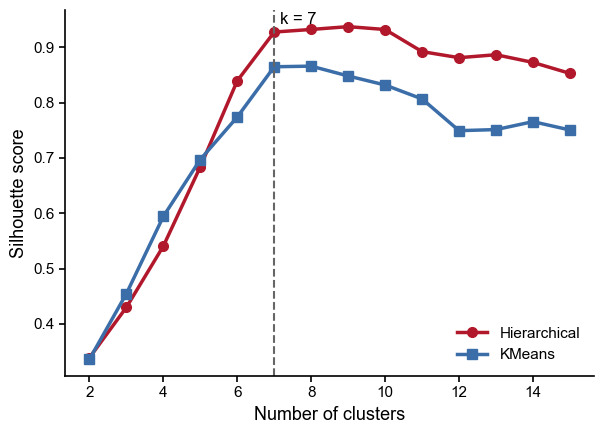


Saved Figure S2 and score table to: ./Figure_S2_cluster_selection


In [43]:
# -*- coding: utf-8 -*-
# ============================================================
# Figure S2. Cluster number selection
# Hierarchical vs KMeans silhouette score
# ============================================================

import os
import pickle
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.nn import Linear, Dropout, Sequential, ReLU
from torch_geometric.nn import GraphNorm, GINEConv, global_mean_pool
from torch_geometric.loader import DataLoader

from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans


# ============================================================
# 0. Paths
# ============================================================

data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
checkpoint_path = '../checkpoints_origin_backup/Unsupervised learning_model_GINE.pth'
output_dir = './Figure_S2_cluster_selection'
os.makedirs(output_dir, exist_ok=True)


# ============================================================
# 1. Args
# ============================================================

parser = argparse.ArgumentParser(description="Figure S2 cluster selection")

parser.add_argument('--device', type=str, default='cuda:7' if torch.cuda.is_available() else 'cpu')
parser.add_argument('--usl_batch_size', type=int, default=256)
parser.add_argument('--usl_hidden_channels', type=int, default=256)
parser.add_argument('--num_classes', type=int, default=2)
parser.add_argument('--dropout', type=float, default=0.5)
parser.add_argument('--max_cluster', type=int, default=15)
parser.add_argument('--min_cluster', type=int, default=2)
parser.add_argument('--random_state', type=int, default=42)

args = parser.parse_args([])

print("Using device:", args.device)


# ============================================================
# 2. Load data
# ============================================================

with open(data_path, 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126]

print("Total molecules:", len(all_data))
print("Positive molecules:", len(positive_samples))


# ============================================================
# 3. Model
# ============================================================

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class Cluster_GINE(torch.nn.Module):
    def __init__(
        self,
        num_node_features,
        num_edge_features,
        hidden_channels,
        num_classes,
        dropout
    ):
        super(Cluster_GINE, self).__init__()

        nn1 = Sequential(
            Linear(num_node_features, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)
        return x


# ============================================================
# 4. Load encoder
# ============================================================

usl_encoder = Cluster_GINE(
    num_node_features=all_data[0].x.shape[1],
    num_edge_features=all_data[0].edge_attr.shape[1],
    hidden_channels=args.usl_hidden_channels,
    num_classes=args.num_classes,
    dropout=args.dropout
).to(args.device)

state_dict = torch.load(checkpoint_path, map_location=args.device)
usl_encoder.load_state_dict(state_dict)

usl_projection = ProjectionHead(
    in_dim=args.usl_hidden_channels,
    proj_dim=128
).to(args.device)

usl_encoder.eval()
usl_projection.eval()


# ============================================================
# 5. Extract positive molecule embeddings
# ============================================================

pos_loader = DataLoader(
    positive_samples,
    batch_size=args.usl_batch_size,
    shuffle=False
)

pos_graph_embeddings = []

with torch.no_grad():
    for data in pos_loader:

        data = data.to(args.device)

        out = usl_encoder(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch
        )

        emb = usl_projection(out)
        pos_graph_embeddings.append(emb.cpu())

pos_graph_embeddings = torch.cat(pos_graph_embeddings, dim=0)
pos_graph_embeddings = F.normalize(pos_graph_embeddings, dim=-1).numpy()

print("Embedding shape:", pos_graph_embeddings.shape)


# ============================================================
# 6. Outlier filtering for hierarchical clustering
# ============================================================

def filter_cluster_outliers(embeddings, cluster_labels, alpha=1.5):
    filtered_embeddings = []
    filtered_labels = []
    filtered_indices = []

    unique_clusters = np.unique(cluster_labels)

    for cluster_id in unique_clusters:
        idx = np.where(cluster_labels == cluster_id)[0]
        cluster_emb = embeddings[idx]

        if len(cluster_emb) < 2:
            continue

        centroid = np.mean(cluster_emb, axis=0).reshape(1, -1)
        cos_sim = cosine_similarity(cluster_emb, centroid)
        distances = 1 - cos_sim.squeeze()

        threshold = distances.mean() + alpha * distances.std()
        mask = distances <= threshold

        filtered_embeddings.append(cluster_emb[mask])
        filtered_labels.append(cluster_labels[idx][mask])
        filtered_indices.append(idx[mask])

    filtered_embeddings = np.vstack(filtered_embeddings)
    filtered_labels = np.concatenate(filtered_labels)
    filtered_indices = np.concatenate(filtered_indices)

    return filtered_embeddings, filtered_labels, filtered_indices


# ============================================================
# 7. Evaluate silhouette scores
# ============================================================

cluster_range = np.arange(args.min_cluster, args.max_cluster + 1)

hierarchical_scores = []
kmeans_scores = []

Z_all = linkage(
    pos_graph_embeddings,
    method='average',
    metric='cosine'
)

for k in cluster_range:

    # ------------------------------
    # Hierarchical clustering
    # ------------------------------
    h_labels_raw = fcluster(
        Z_all,
        t=k,
        criterion='maxclust'
    )

    h_emb_filt, h_labels_filt, _ = filter_cluster_outliers(
        pos_graph_embeddings,
        h_labels_raw,
        alpha=1.5
    )

    h_score = silhouette_score(
        h_emb_filt,
        h_labels_filt,
        metric='cosine'
    )

    hierarchical_scores.append(h_score)

    # ------------------------------
    # KMeans clustering
    # ------------------------------
    kmeans = KMeans(
        n_clusters=k,
        random_state=args.random_state,
        n_init=20
    )

    k_labels = kmeans.fit_predict(pos_graph_embeddings)

    k_score = silhouette_score(
        pos_graph_embeddings,
        k_labels,
        metric='cosine'
    )

    kmeans_scores.append(k_score)


hierarchical_scores = np.array(hierarchical_scores)
kmeans_scores = np.array(kmeans_scores)

best_h_k = cluster_range[np.argmax(hierarchical_scores)]
best_k_k = cluster_range[np.argmax(kmeans_scores)]

print("\n========== Cluster selection results ==========")
print(f"Best hierarchical k: {best_h_k}, silhouette: {hierarchical_scores.max():.4f}")
print(f"Best KMeans k      : {best_k_k}, silhouette: {kmeans_scores.max():.4f}")


# ============================================================
# 8. Plot only Figure S2a
# ============================================================

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

nature_red = '#B2182B'
nature_blue = '#3B6EA8'
nature_gray = '#666666'

target_k = 7

fig, ax = plt.subplots(figsize=(6.2, 4.5))

ax.plot(
    cluster_range,
    hierarchical_scores,
    '-o',
    color=nature_red,
    lw=2.5,
    ms=7,
    label='Hierarchical'
)

ax.plot(
    cluster_range,
    kmeans_scores,
    '-s',
    color=nature_blue,
    lw=2.5,
    ms=7,
    label='KMeans'
)

ax.axvline(
    target_k,
    ls='--',
    lw=1.5,
    color=nature_gray
)

ax.text(
    target_k + 0.15,
    max(np.max(hierarchical_scores), np.max(kmeans_scores)) + 0.005,
    'k = 7',
    fontsize=12
)

ax.set_xlabel('Number of clusters', fontsize=13)
ax.set_ylabel('Silhouette score', fontsize=13)

ax.tick_params(
    axis='both',
    labelsize=11,
    width=1.2,
    length=4
)

ax.legend(
    frameon=False,
    fontsize=11,
    loc='lower right'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, 'Figure_S2_silhouette_hierarchical_kmeans.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 9. Save score table
# ============================================================

score_table = np.column_stack([
    cluster_range,
    hierarchical_scores,
    kmeans_scores
])

np.savetxt(
    os.path.join(output_dir, 'cluster_selection_scores.csv'),
    score_table,
    delimiter=',',
    header='k,hierarchical_silhouette,kmeans_silhouette',
    comments='',
    fmt=['%d', '%.6f', '%.6f']
)

print("\nSaved Figure S2 and score table to:", output_dir)

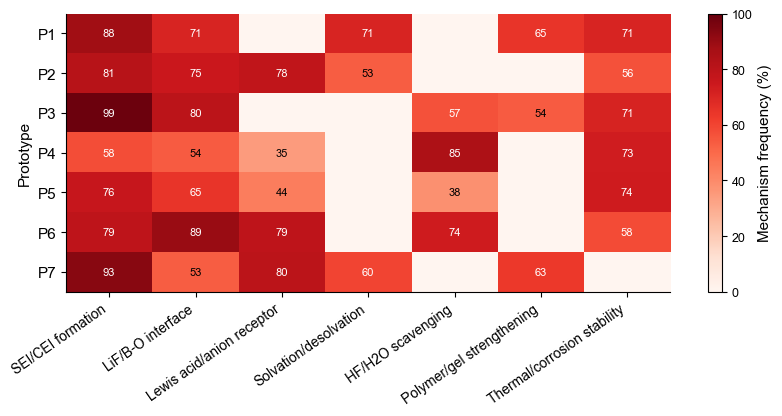

Done.
Saved SI mechanism annotation files in: ./SI_mechanism_annotation

Count table:
    SEI/CEI formation  LiF/B-O interface  Lewis acid/anion receptor  \
P1               15.0               12.0                        0.0   
P2               26.0               24.0                       25.0   
P3               68.0               55.0                        0.0   
P4               15.0               14.0                        9.0   
P5               26.0               22.0                       15.0   
P6               15.0               17.0                       15.0   
P7               28.0               16.0                       24.0   

    Solvation/desolvation  HF/H2O scavenging  Polymer/gel strengthening  \
P1                   12.0                0.0                       11.0   
P2                   17.0                0.0                        0.0   
P3                    0.0               39.0                       37.0   
P4                    0.0               22.0 

In [44]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. Output
# ============================================================
OUT_DIR = "./SI_mechanism_annotation"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 11

# ============================================================
# 1. Data from main Fig.3c
# ============================================================
prototype_records = {
    "P1": 17,
    "P2": 32,
    "P3": 69,
    "P4": 26,
    "P5": 34,
    "P6": 19,
    "P7": 30,
}

mechanism_data = {
    "P1": {
        "SEI/CEI formation": 15,
        "Solvation/desolvation": 12,
        "LiF/B-O interface": 12,
        "Thermal/corrosion stability": 12,
        "Polymer/gel strengthening": 11,
    },
    "P2": {
        "SEI/CEI formation": 26,
        "Lewis acid/anion receptor": 25,
        "LiF/B-O interface": 24,
        "Thermal/corrosion stability": 18,
        "Solvation/desolvation": 17,
    },
    "P3": {
        "SEI/CEI formation": 68,
        "LiF/B-O interface": 55,
        "Thermal/corrosion stability": 49,
        "HF/H2O scavenging": 39,
        "Polymer/gel strengthening": 37,
    },
    "P4": {
        "HF/H2O scavenging": 22,
        "Thermal/corrosion stability": 19,
        "SEI/CEI formation": 15,
        "LiF/B-O interface": 14,
        "Lewis acid/anion receptor": 9,
    },
    "P5": {
        "SEI/CEI formation": 26,
        "Thermal/corrosion stability": 25,
        "LiF/B-O interface": 22,
        "Lewis acid/anion receptor": 15,
        "HF/H2O scavenging": 13,
    },
    "P6": {
        "LiF/B-O interface": 17,
        "Lewis acid/anion receptor": 15,
        "SEI/CEI formation": 15,
        "HF/H2O scavenging": 14,
        "Thermal/corrosion stability": 11,
    },
    "P7": {
        "SEI/CEI formation": 28,
        "Lewis acid/anion receptor": 24,
        "Polymer/gel strengthening": 19,
        "Solvation/desolvation": 18,
        "LiF/B-O interface": 16,
    },
}

mechanisms = [
    "SEI/CEI formation",
    "LiF/B-O interface",
    "Lewis acid/anion receptor",
    "Solvation/desolvation",
    "HF/H2O scavenging",
    "Polymer/gel strengthening",
    "Thermal/corrosion stability",
]

prototypes = list(prototype_records.keys())

# ============================================================
# 2. Build count and frequency tables
# ============================================================
count_df = pd.DataFrame(
    0,
    index=prototypes,
    columns=mechanisms,
    dtype=float
)

for p, tags in mechanism_data.items():
    for m, v in tags.items():
        count_df.loc[p, m] = v

record_s = pd.Series(prototype_records)

freq_df = count_df.div(record_s, axis=0)

# Convert to percentage
freq_pct_df = freq_df * 100

# Save tables
count_df.to_csv(
    os.path.join(OUT_DIR, "Table_S_mechanism_counts.csv")
)

freq_df.to_csv(
    os.path.join(OUT_DIR, "Table_S_mechanism_frequency.csv")
)

freq_pct_df.to_csv(
    os.path.join(OUT_DIR, "Table_S_mechanism_frequency_percent.csv")
)

# Also save a merged long-format table for SI
long_table = []

for p in prototypes:
    for m in mechanisms:
        long_table.append({
            "Prototype": p,
            "Number of records": prototype_records[p],
            "Mechanism": m,
            "Count": int(count_df.loc[p, m]),
            "Frequency": freq_df.loc[p, m],
            "Frequency (%)": freq_pct_df.loc[p, m],
        })

long_df = pd.DataFrame(long_table)

long_df.to_csv(
    os.path.join(OUT_DIR, "Table_S_mechanism_annotation_long_format.csv"),
    index=False
)

# ============================================================
# 3. Heatmap for SI
# ============================================================
fig, ax = plt.subplots(figsize=(8.5, 4.3))

im = ax.imshow(
    freq_pct_df.values,
    aspect="auto",
    cmap="Reds",
    vmin=0,
    vmax=100
)

ax.set_xticks(np.arange(len(mechanisms)))
ax.set_yticks(np.arange(len(prototypes)))

ax.set_xticklabels(
    mechanisms,
    rotation=35,
    ha="right",
    fontsize=10
)

ax.set_yticklabels(
    prototypes,
    fontsize=11
)

# Add text annotation
for i in range(len(prototypes)):
    for j in range(len(mechanisms)):
        value = freq_pct_df.iloc[i, j]

        if value > 0:
            text_color = "white" if value > 55 else "black"
            ax.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mechanism frequency (%)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

ax.set_xlabel("")
ax.set_ylabel("Prototype", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "Figure_S_mechanism_frequency_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 4. Save SI-readable summary table
# ============================================================
summary_rows = []

for p in prototypes:
    sorted_mechs = freq_pct_df.loc[p].sort_values(ascending=False)

    dominant_mechanisms = [
        f"{m} ({v:.1f}%)"
        for m, v in sorted_mechs.items()
        if v > 0
    ]

    summary_rows.append({
        "Prototype": p,
        "Number of annotated records": prototype_records[p],
        "Dominant mechanisms": "; ".join(dominant_mechanisms)
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    os.path.join(OUT_DIR, "Table_S_prototype_mechanism_summary.csv"),
    index=False
)

print("Done.")
print("Saved SI mechanism annotation files in:", OUT_DIR)

print("\nCount table:")
print(count_df)

print("\nFrequency table (%):")
print(freq_pct_df.round(1))